In [2]:
import time
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

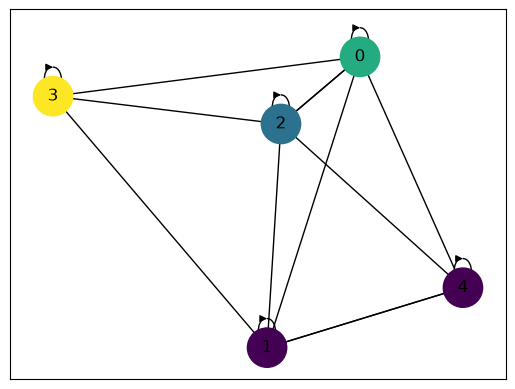

[0.9, 0, 0.9, 0.9, 0]:99
[7.43064897e-28 0.00000000e+00 4.57070327e-28 1.21194711e-27
 0.00000000e+00]


In [4]:
A = np.array([
    [0.15, 0.15, 0.1, 0.2, 0.4],
    [0, 0.55, 0, 0, 0.45],
    [0.3, 0.05, 0.05, 0, 0.6],
    [0, 0.4, 0.1, 0.5, 0],
    [0, 0.3, 0, 0, 0.7]])

G = nx.from_numpy_array(A, create_using=nx.DiGraph)
x0 = np.random.rand(A.shape[0])
x0 = [0.9, 0, 0.9, 0.9, 0]
x = x0
pos = nx.spring_layout(G, seed=0)

assert np.allclose(A @ np.ones(5), np.ones(5))
for t in range(100):
    clear_output(wait=True)
    nodes = nx.draw_networkx_nodes(
    G,
        pos,
        node_color=x,
        cmap=plt.cm.viridis,
        node_size=800
    )
    x = A @ x
    assert (x < 1).all() and (x >= 0).all()
    time.sleep(0.1)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)
    plt.colorbar(nodes)
    plt.show()
    print(f"{x0}:{t}\n{x}")
